# Co-ordinate Geometry

## Euclidean space

```{figure} https://cdn.britannica.com/46/8446-050-BC92B998/Euclid-woodcut-1584.jpg
---
width: 200px
alt: Euclid
figclass : margin
---
[Euclid](https://en.wikipedia.org/wiki/Euclid) (fl 300 BCE, coloured woodcut 1584)
```

The field of computer graphics is almost soley concerned with the manipulation of objects in [**Euclidean space**](https://en.wikipedia.org/wiki/Euclidean_space). Attributed to the Greek mathematician [Euclid](https://en.wikipedia.org/wiki/Euclid), Euclidean space is a representation of physical space where the position of a point in the space can be described by the signed distance along perpendicular real numbers lines called **axes** (singular: axis). 

An $n$-dimensional Euclidean space is defined by $n$ perpendicular real axes and is referred to as $\mathbb{R}^n$. For example, consider the diagram of $\mathbb{R}^3$ in {numref}`R3-figure`. Here we have a representation of a 3-dimensional Euclidean space defined by the 3 axes labelled $x$, $y$ and $z$. This representation uses the [**right-hand rule**](https://en.wikipedia.org/wiki/Right-hand_rule) so-called because if we use the thumb on our right hand to represent the $x$ axis, the index finger for the $y$ axis and the middle finger for the $z$ axis then holding out the right hand palm up with the thumb and index finger at right-angles and the middle finger pointing up then we have the axis configuration shown in {numref}`R3-figure`. Doing similar with the left hand gives the **left-hand rule** where the $x$ axis is pointing in the opposite direction than in the right-hand rule. 

```{figure} ../Images/R3.svg
:name: R3-figure

The position of a point in $\mathbb{R}^3$ can be defined by its co-ordinates $(x, y, z)$.
```

The position of a point in Euclidean space can be defined by its **co-ordinates** which is an ordered set known as a **tuple** where each element contains the signed distances along each axis, e.g., $(x, y, z)$ where $x, y, z \in \mathbb{R}$. 

## Co-ordinate systems

```{figure} https://upload.wikimedia.org/wikipedia/commons/7/73/Frans_Hals_-_Portret_van_Ren%C3%A9_Descartes.jpg
---
figclass: margin
alt: Descartes
figwidth: 200px
---

René Descartes (1596 - 1650) {cite:p}`hals:1700`
```

A **co-ordinate system** is a system that uses a sequence of numbers to determine the position of an object in Euclidean space. The numbers are known as **co-ordinates** and are represented in an ordered set of numbers enclosed in parenthesis known as a **tuple**. The most common example of a co-ordinate system is the **Cartesian co-ordinate system**, named after French mathematician and philosopher <a href="https://en.wikipedia.org/wiki/Ren%C3%A9_Descartes" target="_blank">René Descartes</a>), which uses perpendicular number lines to define points in the space. 

```tikz:: [>=latex',dotted,thick] \draw[->] (0,0) -- (1,1) -- (1,0)
-- (2,0);
:libs: arrows
```

Consider \cref{fig:cartesian co-ordinates} where three number lines called **axes** (singular: axis) are labelled $x$, $y$ and $z$. The position of a point in this space is defined by the co-ordinates $(x, y, z)$ where $x$, $y$ and $z$ are the distances along the axes from zero. Since these values are real numbers a three-dimensional space is often denoted by $\mathbb{R}^3$. 

## Homogeneous co-ordinates

**Homogeneous co-ordinates** are a system of co-ordinates that include an additional value in the tuple. The use of homogeneous co-ordinates is standard practice in computer graphics since they allow us to apply transformations such as translation and projection using matrix multiplication. The Cartesian co-ordinates $(x, y, z)$ are represented using homogeneous co-ordinates as $(wx, wy, wz, w)$ where $w$ is some scalar quantity. Note that when $w=1$ the homogeneous co-ordinates are $(x, y, z, 1)$. 

```{prf:definition}
:class: note

The homogeneous co-ordinates of a point $\mathbf{u}$ in $\mathbb{R}^n$ expressed using the Cartesian co-ordinates is the $(n+1)$-tuple $(\lambda u_1, \lambda u_2, \ldots, \lambda u_n, \lambda)$ where $\lambda \in \mathbb{R}\backslash \{0\}$. 

Note that a point with homogeneous co-ordinates $(u_1, u_2, \ldots, u_n, \lambda)$ has the Cartesian co-ordinates $\left(\dfrac{u_1}{\lambda}, \dfrac{u_2}{\lambda}, \ldots, \dfrac{u_n}{\lambda}\right)$.
```

## Vectors

A **vector** is an object that has length and direction. In mathematical notation vectors are denoted in print using a boldface character, e.g., $\mathbf{a}$ or as an arrow over a character, e.g., $\vec{a}$ or underlined when handwritten, e.g., $\underline{a}$. A vector in $\mathbb{R}^n$ is defined by the signed distance along each axis by an $n$-tuple. For example, let $\mathbf{a}$ be a vector in $\mathbb{R}^3$ defined by the 3-tuple $\mathbf{a} = (a_x, a_y, a_z)$ where $a_x,a_y,a_z \in \mathbb{R}$, then $\mathbf{a}$ can be represented geometrically as

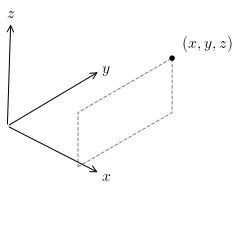

In [148]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

def xycoords(angles, lengths):
    xy = np.zeros((4, 2))
    xy[0,:] = lengths[0] * np.array([np.cos(angles[0]), np.sin(angles[0])])
    for i in range(1, 4):
        xy[i,:] = xy[i-1,:] + np.array([lengths[i] * np.cos(angles[i]), lengths[i] * np.sin(angles[i])])
    return xy


fig, ax = plt.subplots()

angles = np.array([-np.pi/6, np.pi/6, np.pi/2, 7 * np.pi/6])
lengths = np.array([0.75, 1, 0.5, 1])
xy = xycoords(angles, lengths)
plt.fill(xy[:,0], xy[:,1], ec='gray', ls='--', fill=False)

ax.annotate("$x$", xy=(0, 0), xytext=(np.cos(angles[0]), np.sin(angles[0])),arrowprops=dict(arrowstyle="<-"),fontsize=16)
ax.annotate("$y$", xy=(0, 0), xytext=(np.cos(angles[1]), np.sin(angles[1])),arrowprops=dict(arrowstyle="<-"),fontsize=16)
ax.annotate("$z$", xy=(0, 0), xytext=(0, 1),arrowprops=dict(arrowstyle="<-"),fontsize=16)
ax.add_patch(plt.Circle((xy[2,0], xy[2,1]), 0.025, fc="k"))
plt.text(xy[2,0]+0.1, xy[2,1]+0.1, s="$(x, y, z)$", fontsize=16)

plt.axis("off")
ax.set_aspect("equal")
ax.set_xlim([0, 2])
ax.set_ylim([-1, 1])
plt.show()